# Day 30 — Decision Tree Basics: Predictions & Probabilities
- Train a Decision Tree classifier on the Iris dataset.
- Understand root nodes, splits, branches, and leaves.
- Read `gini`, `samples`, `value`, and `class`.
- Make predictions with `predict()`.
- Understand class probabilities with `predict_proba()`.
- Experiment with `max_depth` and observe model complexity.


## 1. Imports and setup

We will use Scikit-Learn's built-in Iris dataset so that no external dataset download is required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NumPy: 2.5.1
Pandas: 3.0.3


## 2. Load and inspect the Iris dataset

The Iris dataset contains measurements of three flower species:
- Setosa
- Versicolor
- Virginica

Features:
- sepal length
- sepal width
- petal length
- petal width


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", feature_names)
print("Classes:", class_names)

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["class"] = [class_names[i] for i in y]

df.head()


X shape: (150, 4)
y shape: (150,)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Train a Decision Tree

We start with `max_depth=2` so that the tree remains small enough to understand visually.

`random_state` makes the experiment reproducible.


In [3]:
tree_clf = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree_clf.fit(X, y)

print("Decision Tree trained successfully.")


Decision Tree trained successfully.


## 4. Visualize the Decision Tree

Look carefully at each node.

Important fields:
- **feature <= threshold** → the question used for the split
- **gini** → impurity of the node
- **samples** → number of training samples reaching the node
- **value** → number of samples belonging to each class
- **class** → predicted class at that node/leaf


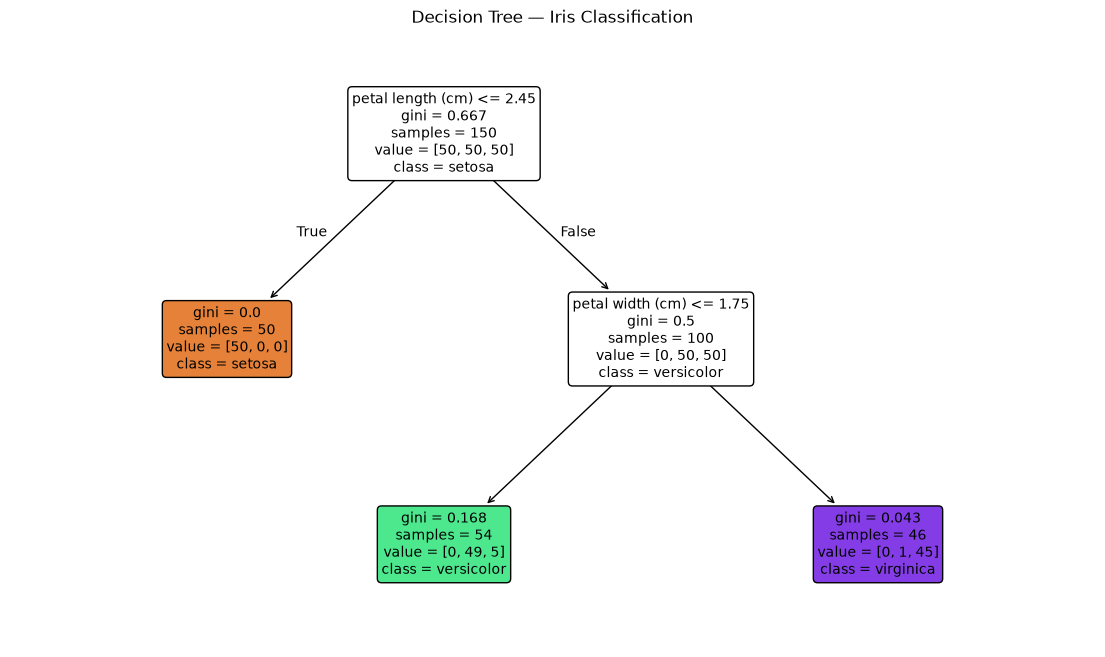

In [4]:
plt.figure(figsize=(14, 8))

plot_tree(
    tree_clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree — Iris Classification")
plt.show()


## 5. Read a Decision Tree node

A node may look conceptually like:

```text
petal length (cm) <= 2.45
gini = 0.667
samples = 150
value = [50, 50, 50]
class = setosa
```

Interpretation:

- The tree asks whether petal length is <= 2.45.
- `samples=150` means 150 training examples reach this node.
- `value=[50, 50, 50]` means 50 examples belong to each Iris class.
- `gini` measures impurity.
- A leaf with `gini=0` is completely pure.


## 6. Calculate Gini impurity manually

For a node:

$$
G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2
$$

where $p_{i,k}$ is the proportion of samples belonging to class $k$.

For `[50, 50, 50]`:

$$
G = 1 - (1/3)^2 - (1/3)^2 - (1/3)^2
$$

Let's calculate it.


In [5]:
class_counts = np.array([50, 50, 50])
probabilities = class_counts / class_counts.sum()

gini = 1 - np.sum(probabilities ** 2)

print("Class probabilities:", probabilities)
print("Gini impurity:", gini)


Class probabilities: [0.33333333 0.33333333 0.33333333]
Gini impurity: 0.6666666666666667


### Try a pure node

If a node contains only one class, for example `[10, 0, 0]`, its Gini impurity should be 0.


In [6]:
class_counts = np.array([10, 0, 0])
probabilities = class_counts / class_counts.sum()

gini = 1 - np.sum(probabilities ** 2)

print("Class probabilities:", probabilities)
print("Gini impurity:", gini)


Class probabilities: [1. 0. 0.]
Gini impurity: 0.0


## 7. Make a prediction with `predict()`

`predict()` returns the class with the highest probability in the leaf reached by the sample.


In [7]:
sample = [[5.0, 3.0, 1.5, 0.2]]

prediction = tree_clf.predict(sample)

print("Predicted class index:", prediction[0])
print("Predicted class name:", class_names[prediction[0]])


Predicted class index: 0
Predicted class name: setosa


## 8. Get probabilities with `predict_proba()`

Unlike `predict()`, `predict_proba()` returns the estimated probability for every class.

The probabilities come from the class distribution of the leaf reached by the sample.


In [8]:
probabilities = tree_clf.predict_proba(sample)

print("Probability array:")
print(probabilities)

for class_name, probability in zip(class_names, probabilities[0]):
    print(f"{class_name:12s}: {probability:.2%}")


Probability array:
[[1. 0. 0.]]
setosa      : 100.00%
versicolor  : 0.00%
virginica   : 0.00%


## 9. Test several samples

Try to predict the class of flowers with different measurements.


In [9]:
samples = np.array([
    [5.0, 3.0, 1.5, 0.2],
    [6.0, 3.0, 4.5, 1.5],
    [6.5, 3.0, 5.5, 2.0]
])

predictions = tree_clf.predict(samples)
probabilities = tree_clf.predict_proba(samples)

for i, sample in enumerate(samples):
    print("Sample:", sample)
    print("Prediction:", class_names[predictions[i]])
    print("Probabilities:", dict(zip(class_names, probabilities[i].round(3))))
    print("-" * 60)


Sample: [5.  3.  1.5 0.2]
Prediction: setosa
Probabilities: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}
------------------------------------------------------------
Sample: [6.  3.  4.5 1.5]
Prediction: versicolor
Probabilities: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(0.907), np.str_('virginica'): np.float64(0.093)}
------------------------------------------------------------
Sample: [6.5 3.  5.5 2. ]
Prediction: virginica
Probabilities: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(0.022), np.str_('virginica'): np.float64(0.978)}
------------------------------------------------------------


## 10. Understand a leaf probability manually

Suppose a leaf contains:

```text
Setosa      = 7
Versicolor  = 2
Virginica   = 1
```

Then:

- Setosa = 70%
- Versicolor = 20%
- Virginica = 10%

The predicted class is Setosa because it has the largest proportion.

Run the calculation below.


In [10]:
leaf_counts = np.array([7, 2, 1])
leaf_probabilities = leaf_counts / leaf_counts.sum()

for class_name, probability in zip(class_names, leaf_probabilities):
    print(f"{class_name:12s}: {probability:.0%}")

print("Predicted class:", class_names[np.argmax(leaf_probabilities)])


setosa      : 70%
versicolor  : 20%
virginica   : 10%
Predicted class: setosa


## 11. Train/test split

So far we trained on the entire dataset. Now let's create a training set and a test set so we can evaluate generalization.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tree_test = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree_test.fit(X_train, y_train)

y_pred = tree_test.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


Test accuracy: 0.9333333333333333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 12. Experiment with `max_depth`

`max_depth` controls how deeply the tree can grow.

Try different values and compare training and test accuracy.

Think about:
- Does increasing depth improve training accuracy?
- Does test accuracy always improve?
- When does the tree start becoming unnecessarily complex?


In [12]:
depths = range(1, 11)

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    results.append({
        "max_depth": depth,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy
    })

results_df = pd.DataFrame(results)
results_df


,max_depth,train_accuracy,test_accuracy
0,1,0.666667,0.666667
1,2,0.966667,0.933333
2,3,0.983333,0.966667
3,4,0.991667,0.933333
4,5,1.000000,0.933333
5,6,1.000000,0.933333
6,7,1.000000,0.933333
7,8,1.000000,0.933333
8,9,1.000000,0.933333
9,10,1.000000,0.933333


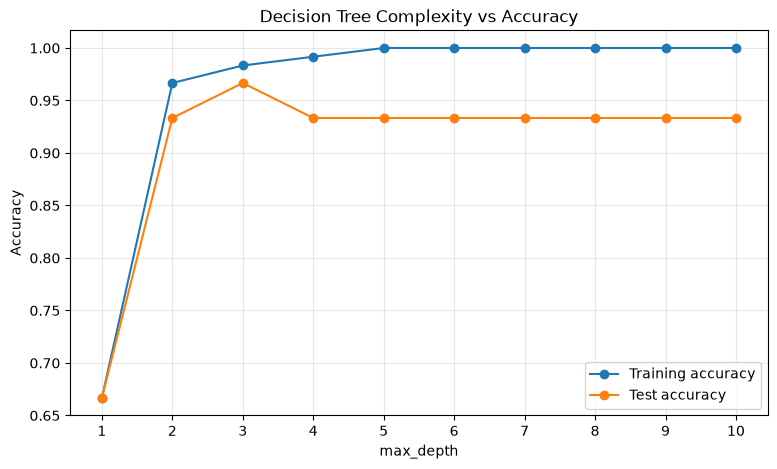

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    results_df["max_depth"],
    results_df["train_accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    results_df["max_depth"],
    results_df["test_accuracy"],
    marker="o",
    label="Test accuracy"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Complexity vs Accuracy")
plt.xticks(list(depths))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 13. Important experiment — remove `max_depth`

Now allow the Decision Tree to grow without this depth restriction.

Compare the resulting tree with the depth-2 tree.


In [14]:
unrestricted_tree = DecisionTreeClassifier(
    random_state=42
)

unrestricted_tree.fit(X_train, y_train)

print("Training accuracy:", unrestricted_tree.score(X_train, y_train))
print("Test accuracy:", unrestricted_tree.score(X_test, y_test))
print("Tree depth:", unrestricted_tree.get_depth())
print("Number of leaves:", unrestricted_tree.get_n_leaves())


Training accuracy: 1.0
Test accuracy: 0.9333333333333333
Tree depth: 5
Number of leaves: 8


## 14. Visualize the unrestricted tree

This tree may be considerably larger.

That is an important practical lesson:

> Decision Trees can become very complex and overfit unless their growth is controlled.


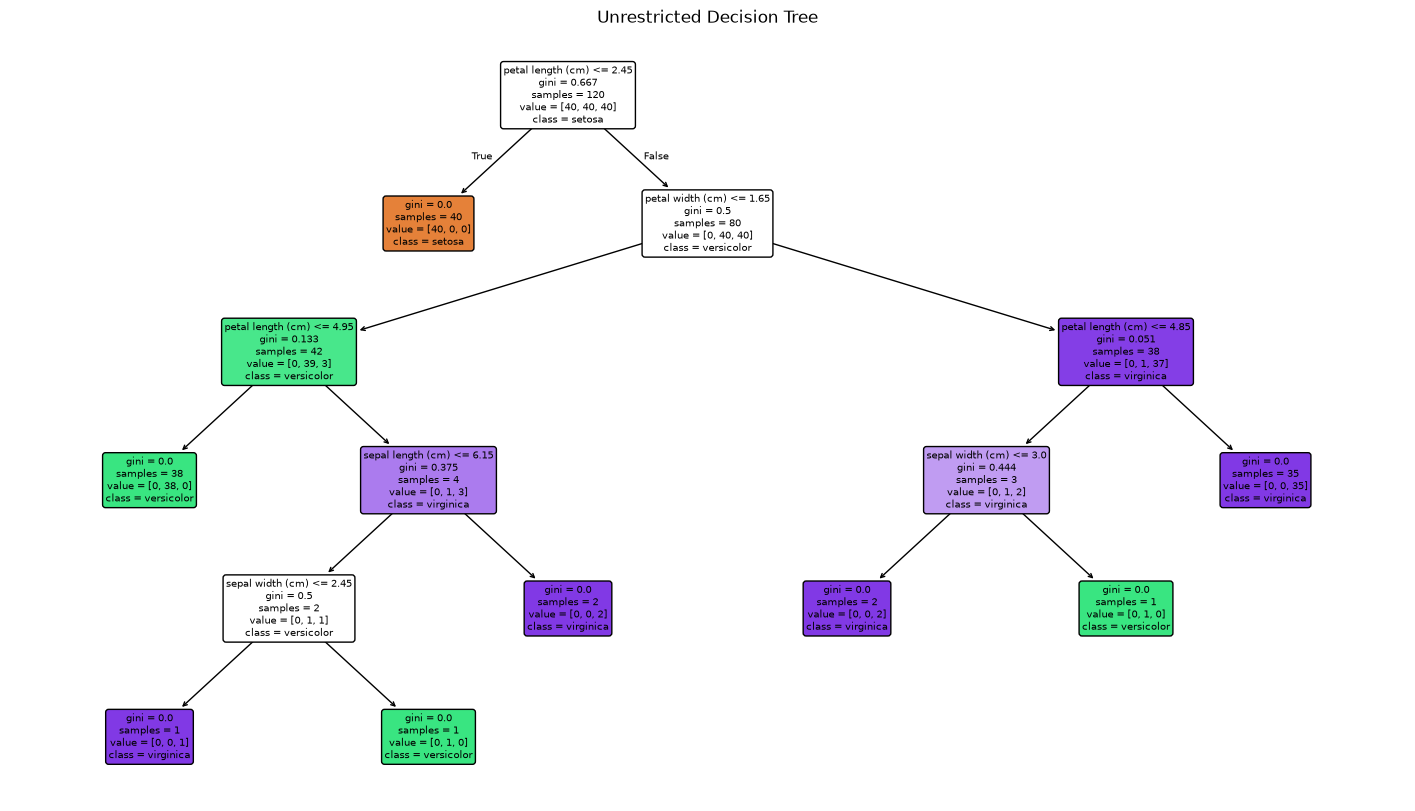

In [15]:
plt.figure(figsize=(18, 10))

plot_tree(
    unrestricted_tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=7
)

plt.title("Unrestricted Decision Tree")
plt.show()


## 15. Inspect the model structure programmatically

Scikit-Learn exposes useful information about the trained tree.


In [16]:
print("Tree depth:", tree_clf.get_depth())
print("Number of leaves:", tree_clf.get_n_leaves())
print("Number of features used:", tree_clf.n_features_in_)


Tree depth: 2
Number of leaves: 3
Number of features used: 4


In [17]:
challenge_sample = [[5.8, 2.7, 5.1, 1.9]]

prediction = tree_clf.predict(challenge_sample)[0]
probabilities = tree_clf.predict_proba(challenge_sample)[0]

print("Prediction:", class_names[prediction])
print("Probabilities:")

for class_name, probability in zip(class_names, probabilities):
    print(f"  {class_name:12s}: {probability:.2%}")


Prediction: virginica
Probabilities:
  setosa      : 0.00%
  versicolor  : 2.17%
  virginica   : 97.83%


# Key Takeaways

### Decision Tree
A tree makes predictions by repeatedly applying feature/threshold questions.

### Split
A split divides the training samples into child nodes.

### Gini impurity
Measures how mixed the classes are in a node.

### Leaf
The final node reached by a sample.

### `predict()`
Returns the most likely class.

### `predict_proba()`
Returns the class distribution of the reached leaf.

### `max_depth`
Controls tree complexity and helps reduce overfitting.

### Remember this pipeline

```text
Training data
     ↓
Find useful split
     ↓
Split data
     ↓
Repeat recursively
     ↓
Leaf nodes
     ↓
Prediction / probability
```

**Next concept:** CART's splitting objective, Gini impurity in greater depth, and Decision Tree regularization.
